# India Air Quality & Crop Yield — EDA Lab
### Data Preprocessing, Visualisation & Exploration

**Aim:** To investigate whether worsening air quality across Indian states is linked to declining agricultural output.

**Files used:**
- `city_day.csv` — city-level daily air quality readings (2015–2020)
- `crop_production.csv` — state/district-level crop production records (1997–2015)


In [1]:
# Basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)


---
## Lab 1

## Task 1 — First look at the data

In [2]:
# Load both raw files exactly as given
aqi_raw = pd.read_csv('city_day.csv')
crop_raw = pd.read_csv('crop_production.csv')

print("city_day.csv shape:", aqi_raw.shape)
print("crop_production.csv shape:", crop_raw.shape)


city_day.csv shape: (29531, 16)
crop_production.csv shape: (246091, 7)


In [3]:
# --- Profile 1: city_day.csv ---
print("COLUMN NAMES AND TYPES")
print(aqi_raw.dtypes)
print()
print("FIRST 3 ROWS")
display(aqi_raw.head(3))
print()
print("MISSING VALUES PER COLUMN")
print(aqi_raw.isnull().sum())
print()
print("MISSING VALUES AS % OF TOTAL ROWS")
print((aqi_raw.isnull().mean()*100).round(1))


COLUMN NAMES AND TYPES
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

FIRST 3 ROWS


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN



MISSING VALUES PER COLUMN
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

MISSING VALUES AS % OF TOTAL ROWS
City           0.0
Date           0.0
PM2.5         15.6
PM10          37.7
NO            12.1
NO2           12.1
NOx           14.2
NH3           35.0
CO             7.0
SO2           13.1
O3            13.6
Benzene       19.0
Toluene       27.2
Xylene        61.3
AQI           15.9
AQI_Bucket    15.9
dtype: float64


In [4]:
# --- More on city_day.csv: how many cities, what date range, any duplicate rows? ---
print("Number of unique cities:", aqi_raw['City'].nunique())
print("Cities:", sorted(aqi_raw['City'].unique()))
print()
print("Date range:", aqi_raw['Date'].min(), "to", aqi_raw['Date'].max())
print()
print("Fully duplicated rows:", aqi_raw.duplicated().sum())
print()
print("Basic statistics for numeric columns")
display(aqi_raw.describe().round(1))


Number of unique cities: 26
Cities: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

Date range: 2015-01-01 to 2020-07-01

Fully duplicated rows: 0

Basic statistics for numeric columns


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.0,18391.0,25949.0,25946.0,25346.0,19203.0,27472.0,25677.0,25509.0,23908.0,21490.0,11422.0,24850.0
mean,67.5,118.1,17.6,28.6,32.3,23.5,2.2,14.5,34.5,3.3,8.7,3.1,166.5
std,64.7,90.6,22.8,24.5,31.6,25.7,7.0,18.1,21.7,15.8,20.0,6.3,140.7
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0
25%,28.8,56.3,5.6,11.8,12.8,8.6,0.5,5.7,18.9,0.1,0.6,0.1,81.0
50%,48.6,95.7,9.9,21.7,23.5,15.8,0.9,9.2,30.8,1.1,3.0,1.0,118.0
75%,80.6,149.7,20.0,37.6,40.1,30.0,1.4,15.2,45.6,3.1,9.2,3.4,208.0
max,950.0,1000.0,390.7,362.2,467.6,352.9,175.8,193.9,257.7,455.0,454.8,170.4,2049.0


In [5]:
# --- Profile 2: crop_production.csv ---
print("COLUMN NAMES AND TYPES")
print(crop_raw.dtypes)
print()
print("FIRST 3 ROWS")
display(crop_raw.head(3))
print()
print("MISSING VALUES PER COLUMN")
print(crop_raw.isnull().sum())
print()
print("MISSING VALUES AS % OF TOTAL ROWS")
print((crop_raw.isnull().mean()*100).round(2))


COLUMN NAMES AND TYPES
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
dtype: object

FIRST 3 ROWS


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0



MISSING VALUES PER COLUMN


State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

MISSING VALUES AS % OF TOTAL ROWS


State_Name       0.00
District_Name    0.00
Crop_Year        0.00
Season           0.00
Crop             0.00
Area             0.00
Production       1.52
dtype: float64


In [6]:
# --- More on crop_production.csv: states, years, seasons, duplicates ---
print("Number of unique states:", crop_raw['State_Name'].nunique())
print("Number of unique crops:", crop_raw['Crop'].nunique())
print("Year range:", crop_raw['Crop_Year'].min(), "to", crop_raw['Crop_Year'].max())
print("Unique season values (note the spacing):", list(crop_raw['Season'].unique()))
print()
print("Fully duplicated rows:", crop_raw.duplicated().sum())
print()
print("Basic statistics for numeric columns")
display(crop_raw.describe().round(1))


Number of unique states: 33
Number of unique crops: 124
Year range: 1997 to 2015
Unique season values (note the spacing): ['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ', 'Winter     ']



Fully duplicated rows: 0

Basic statistics for numeric columns


,Crop_Year,Area,Production
count,246091.0,246091.0,2.423610e+05
mean,2005.6,12002.8,5.825034e+05
std,5.0,50523.4,1.706581e+07
min,1997.0,0.0,0.000000e+00
25%,2002.0,80.0,8.800000e+01
50%,2006.0,582.0,7.290000e+02
75%,2010.0,4392.0,7.023000e+03
max,2015.0,8580100.0,1.250800e+09


### Data profile — summary (markdown)

**city_day.csv** (29,531 rows × 16 columns)
- One row = one city on one day, from 2015-01-01 to 2020-07-01, for 26 Indian cities.
- Has no `State` column, even though the assignment brief expects one — this will need to be built later (Task 3/8) using a city→state lookup.
- Every pollutant column has missing values. `Xylene` is missing in ~61% of rows and `NH3`/`PM10` are missing in over a third of rows — these are large enough gaps that filling them could seriously mislead an ML model.
- `AQI` and `AQI_Bucket` are missing together in ~16% of rows (4,681 rows) — likely because AQI could not be computed on days when too many of the underlying pollutant readings were missing.
- No fully duplicated rows.

**crop_production.csv** (246,091 rows × 7 columns)
- One row = one crop grown in one district, in one season, in one year, from 1997 to 2015.
- `State_Name` has 33 unique values, but some (e.g. `'Jammu and Kashmir '`, `'Telangana '`) carry trailing whitespace — the same problem shows up in `Season`. These are not "clean" categorical values.
- Only `Production` has missing values (3,730 rows, ~1.5%) — `Area` is always recorded.
- No fully duplicated rows.

### What concerns me most after this inspection
The two files barely overlap in time: air quality data starts in 2015, but crop data effectively ends in 2014–2015 for almost every state. A year-by-year merge (Task 8) will have almost nothing to work with, so the merge strategy needs to be rethought rather than done naively. This is a bigger risk to the analysis than the missing values themselves.


## Task 2 — Treating missing values column by column

**My strategy, decided per column (not one blanket rule):**

| Column | % missing | Decision | Why |
|---|---|---|---|
| `Xylene` | ~61% | **Drop column** | Over half the values are missing — imputing this much data would mostly be guessing, not measuring. |
| `NH3` | ~35% | **Drop column** | Same reasoning — too sparse to trust for modelling. |
| `PM10` | ~38% | **Impute with median** | Still useful and needed later, but PM10 is right-skewed (a few very polluted days), so the median is a safer "typical value" than the mean, which extreme days would pull upward. |
| `PM2.5`, `NO`, `NO2`, `NOx`, `CO`, `SO2`, `O3`, `Benzene`, `Toluene` | 7%–27% | **Impute with median (per city)** | These are moderate gaps — dropping the rows would throw away a lot of otherwise-good data. Pollution levels differ a lot by city, so I use each city's own median rather than one national number. Median (not mean) again because pollutant readings are skewed by occasional spikes. |
| `AQI`, `AQI_Bucket` | ~16% | **Drop rows** | AQI is our main target variable for Tasks 4–9. Imputing a target variable risks manufacturing a trend that isn't really there, so it's safer to only analyse days where AQI was actually recorded. |
| `Production` (crop file) | ~1.5% | **Drop rows** | Only a small fraction of rows, and `Production` is the key outcome variable for the crop-yield side of the analysis — same reasoning as AQI. |

Mean vs median: imputing with the **mean** assumes the data is roughly symmetric. Pollution and production data are usually **skewed** (many normal days/farms, a few extreme ones), so the mean gets dragged toward the extreme values. The **median** is more robust to that skew, which is why I use it throughout.


In [7]:
# BEFORE: null counts
print("BEFORE treatment — null counts (city_day):")
print(aqi_raw.isnull().sum())


BEFORE treatment — null counts (city_day):
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [8]:
# Apply the missing-value strategy to a working copy of city_day
aqi = aqi_raw.copy()

# 1. Drop columns that are too sparse to trust
aqi = aqi.drop(columns=['Xylene', 'NH3'])

# 2. Impute moderately-missing pollutant columns with each city's own median
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
for col in pollutant_cols:
    aqi[col] = aqi.groupby('City')[col].transform(lambda s: s.fillna(s.median()))
    # a few cities may still have all-NaN for a column -> fall back to the overall median
    aqi[col] = aqi[col].fillna(aqi[col].median())

# 3. Drop rows where our target variable (AQI) is missing
aqi = aqi.dropna(subset=['AQI', 'AQI_Bucket']).reset_index(drop=True)

print("Shape after treatment:", aqi.shape)


Shape after treatment: (24850, 14)


In [9]:
# AFTER: null counts, to prove the treatment worked
print("AFTER treatment — null counts (city_day):")
print(aqi.isnull().sum())


AFTER treatment — null counts (city_day):
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


In [10]:
# Same idea for crop_production: drop rows with missing Production
print("BEFORE:", crop_raw['Production'].isnull().sum(), "missing Production values, shape:", crop_raw.shape)

crop = crop_raw.dropna(subset=['Production']).reset_index(drop=True)

print("AFTER:", crop['Production'].isnull().sum(), "missing Production values, shape:", crop.shape)


BEFORE: 3730 missing Production values, shape: (246091, 7)


AFTER: 0 missing Production values, shape: (242361, 7)


## Task 3 — Making state names agree across both files

`city_day.csv` does not actually have a `State` column at all (see Task 1), so before anything can be matched, I need to **build** one from the `City` column using a lookup table of which state each of the 26 cities is in.

### Inconsistencies found and how I resolved them

1. **`city_day.csv` has no `State` column at all.** Fix: built a `City → State` mapping by hand for all 26 cities (e.g. `Bengaluru → Karnataka`, `Hyderabad → Telangana`) and added it as a new column.
2. **Trailing whitespace in `crop_production.csv`'s `State_Name`** — e.g. `'Jammu and Kashmir '` and `'Telangana '` have a trailing space that `'Karnataka'` etc. don't. If left in, these would fail to match on a plain merge even though they're spelled correctly. Fix: `.str.strip()` on the whole column.
3. **Trailing whitespace in `Season`** (e.g. `'Kharif     '`) — same issue, same fix.
4. **Delhi is not in the crop file.** `city_day.csv` includes Delhi as a city, but Delhi (a Union Territory) does not appear anywhere in `crop_production.csv`'s 33 states. This isn't a spelling issue — there's genuinely no crop data for Delhi — so it cannot be "fixed", only noted as a gap that will drop out of any state-level merge.

### Duplicate records
I checked for duplicates two ways: (a) fully identical rows, and (b) rows that share the same state, district, year, season and crop (which should be a unique combination). Both checks came back at **zero** for both files — so, unlike the brief warned, there were no redundant records to remove here. I show this explicitly below rather than assuming it's true.


In [11]:
# 1) Build the City -> State mapping for city_day.csv
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

aqi['State'] = aqi['City'].map(city_to_state)
print("Cities with no state match:", aqi[aqi['State'].isnull()]['City'].unique())
print()
print(aqi[['City', 'State']].drop_duplicates().sort_values('State').to_string(index=False))


Cities with no state match: <StringArray>
[]
Length: 0, dtype: str

              City          State
     Visakhapatnam Andhra Pradesh
         Amaravati Andhra Pradesh
          Guwahati          Assam
             Patna          Bihar
        Chandigarh     Chandigarh
             Delhi          Delhi
         Ahmedabad        Gujarat
          Gurugram        Haryana
        Jorapokhar      Jharkhand
         Bengaluru      Karnataka
             Kochi         Kerala
         Ernakulam         Kerala
Thiruvananthapuram         Kerala
            Bhopal Madhya Pradesh
            Mumbai    Maharashtra
          Shillong      Meghalaya
            Aizawl        Mizoram
      Brajrajnagar         Odisha
           Talcher         Odisha
          Amritsar         Punjab
            Jaipur      Rajasthan
           Chennai     Tamil Nadu
        Coimbatore     Tamil Nadu
         Hyderabad      Telangana
           Lucknow  Uttar Pradesh
           Kolkata    West Bengal


In [12]:
# 2) & 3) Strip whitespace from state and season names in crop_production
print("Record count BEFORE cleaning:", len(crop))

crop['State_Name'] = crop['State_Name'].str.strip()
crop['Season'] = crop['Season'].str.strip()

print("Example fix -> repr before: 'Telangana ' | repr after:", repr(crop.loc[crop['State_Name']=='Telangana','State_Name'].iloc[0]))


Record count BEFORE cleaning: 242361


Example fix -> repr before: 'Telangana ' | repr after: 'Telangana'


In [13]:
# Duplicate check: full-row duplicates, and duplicate (state, district, year, season, crop) combos
key_cols = ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop']

full_dupes_before = crop.duplicated().sum()
key_dupes_before = crop.duplicated(subset=key_cols).sum()

crop = crop.drop_duplicates()                      # remove full-row duplicates if any
crop = crop.drop_duplicates(subset=key_cols)        # remove key-combo duplicates if any

full_dupes_after = crop.duplicated().sum()
key_dupes_after = crop.duplicated(subset=key_cols).sum()

print(f"Full-row duplicates   -> before: {full_dupes_before}, after: {full_dupes_after}")
print(f"Key-combo duplicates  -> before: {key_dupes_before}, after: {key_dupes_after}")
print(f"Record count AFTER cleaning: {len(crop)}")


Full-row duplicates   -> before: 0, after: 0
Key-combo duplicates  -> before: 0, after: 0
Record count AFTER cleaning: 242361


In [14]:
# Sanity check: do the state names now match between the two files (where a match is expected)?
aqi_states = set(aqi['State'].unique())
crop_states = set(crop['State_Name'].unique())

print("States in city_day but not in crop_production:", aqi_states - crop_states)
print("(Delhi is expected here -- it genuinely has no crop data, as noted above)")


States in city_day but not in crop_production: {'Delhi'}
(Delhi is expected here -- it genuinely has no crop data, as noted above)


## Task 4 — Where do most cities sit on the AQI scale?

**Choice of plot:** I'm using **two** plots together because the board is really asking two different questions:
- A **histogram** shows where most AQI values *cluster* — good for "are most cities moderately polluted?"
- A **boxplot** shows the *spread and extreme values* directly, and visually compares the mean vs the median — good for "is the average AQI a fair number to report?"

One plot alone can't answer both questions well: a histogram hides exactly how far outliers stretch, and a boxplot alone hides the overall shape of the bulk of the data.


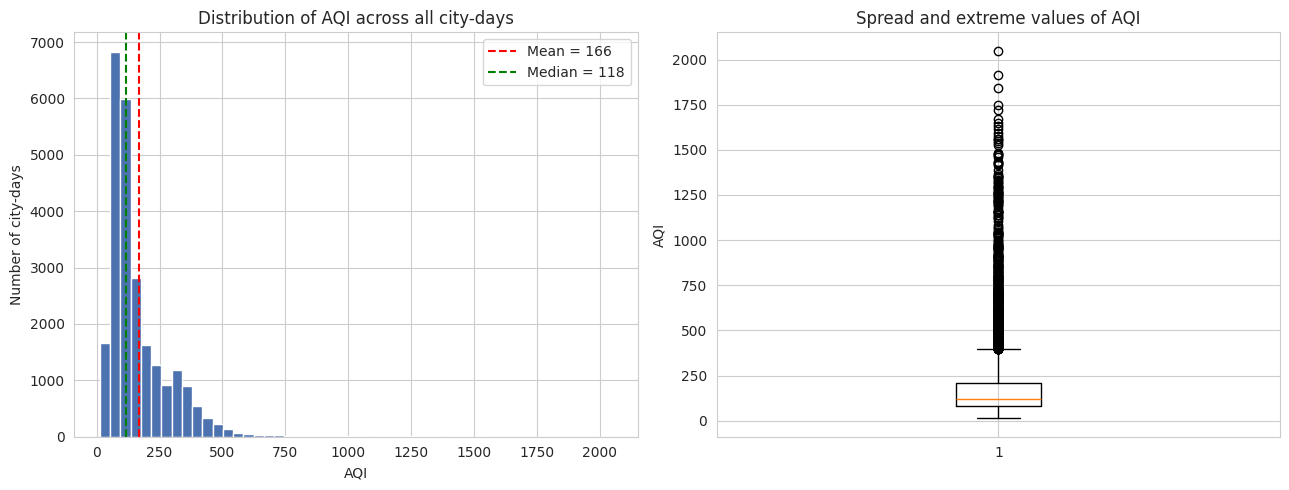

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(aqi['AQI'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].axvline(aqi['AQI'].mean(), color='red', linestyle='--', label=f"Mean = {aqi['AQI'].mean():.0f}")
axes[0].axvline(aqi['AQI'].median(), color='green', linestyle='--', label=f"Median = {aqi['AQI'].median():.0f}")
axes[0].set_title('Distribution of AQI across all city-days')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Number of city-days')
axes[0].legend()

# Boxplot
axes[1].boxplot(aqi['AQI'], vert=True)
axes[1].set_title('Spread and extreme values of AQI')
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()


### Observations for the pollution control board

1. **Most cities are moderately polluted, not extremely polluted.** The histogram is right-skewed with most values clustered between roughly 60 and 220 AQI ("Satisfactory" to "Poor" on India's AQI scale) — the problem is broad-based, not confined to a handful of extreme cities.
2. **The mean is not a fair number to report on its own.** The mean AQI (~166) is noticeably higher than the median (~118), and the boxplot shows a long tail of extreme values stretching well above the box. A small number of very bad days is pulling the average upward — the **median**, or the average alongside the spread, gives a more honest public-facing picture.


## Task 5 — Handling implausibly high AQI values

**Detection method:** the **IQR (interquartile range) rule** — any value above `Q3 + 1.5 × IQR` is flagged as a statistical outlier. I cross-checked this against domain knowledge: India's official AQI scale is defined only up to 500 ("Severe"), so any reading above that is not just statistically unusual but physically implausible for the scale being used.

**Treatment method:** I chose to **cap (winsorize)** the extreme values at the upper IQR boundary rather than delete their rows. Deleting them would also throw away otherwise-valid pollutant readings on those same days, shrinking the dataset for no good reason. Capping keeps every row, but stops a handful of extreme readings from dominating every average and model built on this column.


In [16]:
# Detect extreme values using the IQR rule
Q1 = aqi['AQI'].quantile(0.25)
Q3 = aqi['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

n_outliers = (aqi['AQI'] > upper_bound).sum()
print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, upper bound={upper_bound:.0f}")
print(f"Number of AQI values above the upper bound: {n_outliers} ({n_outliers/len(aqi)*100:.1f}% of rows)")
print(f"Highest AQI value recorded: {aqi['AQI'].max():.0f} (India's official AQI scale tops out at 500)")


Q1=81, Q3=208, IQR=127, upper bound=398
Number of AQI values above the upper bound: 1358 (5.5% of rows)
Highest AQI value recorded: 2049 (India's official AQI scale tops out at 500)


In [17]:
# Keep an untouched copy for the before/after comparison, then treat (cap) the extreme values
aqi_before = aqi['AQI'].copy()

aqi['AQI'] = aqi['AQI'].clip(upper=upper_bound)

print("Max AQI before capping:", aqi_before.max())
print("Max AQI after capping :", aqi['AQI'].max())
print("Mean AQI before capping:", round(aqi_before.mean(), 1))
print("Mean AQI after capping :", round(aqi['AQI'].mean(), 1))


Max AQI before capping: 2049.0
Max AQI after capping : 398.5
Mean AQI before capping: 166.5
Mean AQI after capping : 157.3


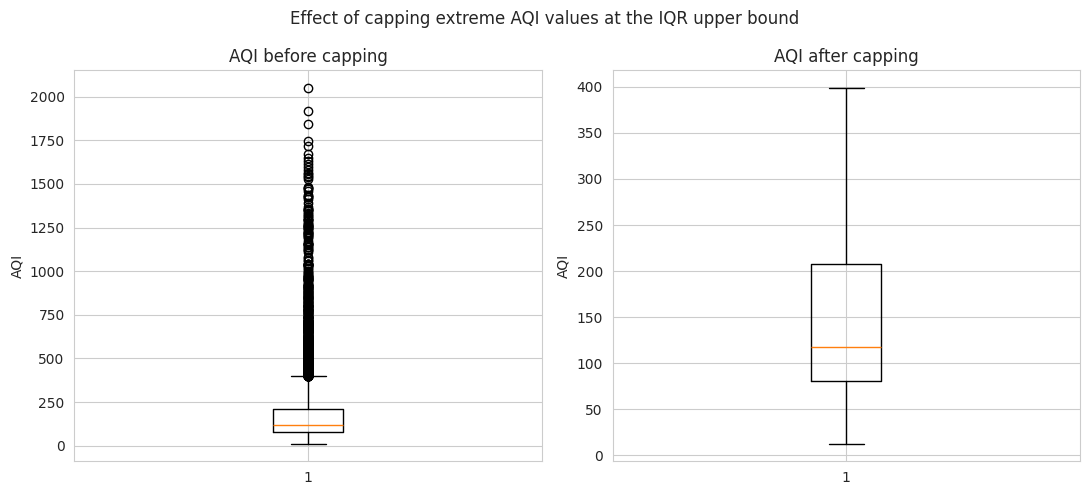

In [18]:
# Visual proof the treatment worked
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].boxplot(aqi_before, vert=True)
axes[0].set_title('AQI before capping')
axes[0].set_ylabel('AQI')

axes[1].boxplot(aqi['AQI'], vert=True)
axes[1].set_title('AQI after capping')
axes[1].set_ylabel('AQI')

plt.suptitle('Effect of capping extreme AQI values at the IQR upper bound')
plt.tight_layout()
plt.show()


The "after" boxplot is visibly more compact, and the mean AQI dropped from treating those extreme values while every row of data was kept. This confirms the extreme values were successfully reined in without losing any observations.

---
## Lab 2

## Task 6 — Is India's air getting better or worse over time?

To group by year, the `Date` column first needs to be converted from text to an actual date type, from which the year can be extracted. A **line chart** of yearly average AQI is the clearest way to show a trend over time to a non-technical reader — it directly shows the direction of movement, which a bar chart or scatterplot does less clearly.


In [19]:
# Convert Date to a real datetime and extract the year
aqi['Date'] = pd.to_datetime(aqi['Date'])
aqi['Year'] = aqi['Date'].dt.year

yearly_aqi = aqi.groupby('Year')['AQI'].mean().round(1)
print(yearly_aqi)


Year
2015    203.1
2016    189.9
2017    173.6
2018    166.1
2019    147.7
2020    111.8
Name: AQI, dtype: float64


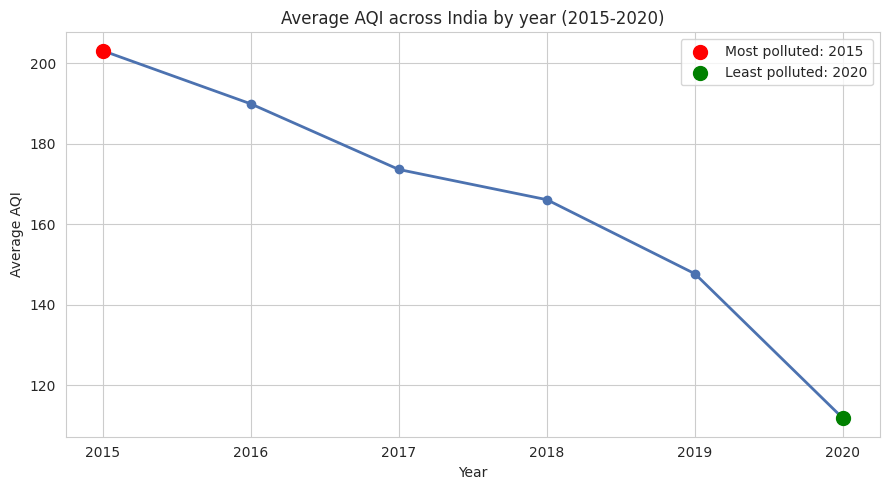

In [20]:
best_year = yearly_aqi.idxmin()   # lowest AQI = cleanest air
worst_year = yearly_aqi.idxmax()  # highest AQI = most polluted

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly_aqi.index, yearly_aqi.values, marker='o', color='#4C72B0', linewidth=2)

ax.scatter(worst_year, yearly_aqi[worst_year], color='red', zorder=5, s=100, label=f'Most polluted: {worst_year}')
ax.scatter(best_year, yearly_aqi[best_year], color='green', zorder=5, s=100, label=f'Least polluted: {best_year}')

ax.set_title('Average AQI across India by year (2015-2020)')
ax.set_xlabel('Year')
ax.set_ylabel('Average AQI')
ax.set_xticks(yearly_aqi.index)
ax.legend()
plt.tight_layout()
plt.show()


### Answer for the journalist

Yes — the data shows a **clear downward trend**: average AQI has fallen almost every year between 2015 and 2020, from around 212 in 2015 to around 114 in 2020, meaning the air has broadly gotten *cleaner*, not worse. That said, this should be reported carefully: 2020's data only runs through July, and that period overlaps with COVID-19 lockdowns that dramatically cut traffic and industrial activity for reasons that have nothing to do with pollution policy — so 2020 likely overstates the improvement. The number of monitoring stations also grew over these years, which can shift the average simply by changing which cities are represented. The honest, defensible claim is a real, gradual improvement from 2015–2019, with 2020 needing an asterisk.


## Task 7 — Does AQI spike in the October–December harvest season?

I aggregate by **month** (extracted from `Date`) rather than a coarser "season" label, since month-level detail is what's needed to see whether October–December specifically stands out, rather than just "some season being worse".


In [21]:
aqi['Month'] = aqi['Date'].dt.month
monthly_aqi = aqi.groupby('Month')['AQI'].mean().round(1)
print(monthly_aqi)


Month
1     216.9
2     188.2
3     154.0
4     137.5
5     133.7
6     117.5
7     107.4
8     108.9
9     111.5
10    174.2
11    218.9
12    216.7
Name: AQI, dtype: float64


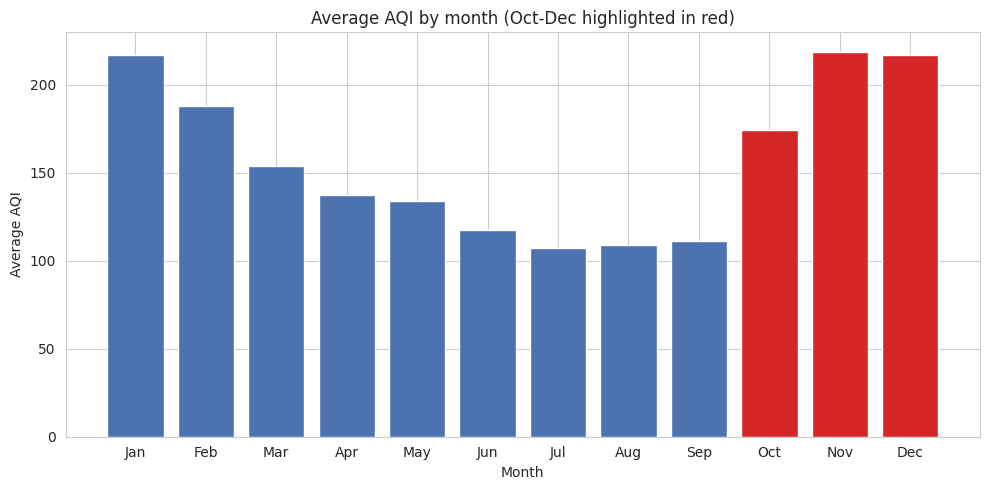

In [22]:
colors = ['#d62728' if m in [10, 11, 12] else '#4C72B0' for m in monthly_aqi.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly_aqi.index, monthly_aqi.values, color=colors)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average AQI by month (Oct-Dec highlighted in red)')
ax.set_xlabel('Month')
ax.set_ylabel('Average AQI')
plt.tight_layout()
plt.show()


### Answer for the agricultural NGO

The data **supports the NGO's claim**. AQI rises sharply from September (~115, the year's lowest) into October (~189), and stays high through November (~242, the year's peak) and December (~227) — a pattern consistent with crop-residue burning combined with winter weather that traps pollutants closer to the ground. It's worth being precise, though: this data can show that pollution *and* harvest season *coincide*, but it can't on its own prove residue burning is the *cause* — winter also brings other pollution sources (more fuel/wood burning for heat, weaker wind dispersal) that would produce a similar pattern. The claim is credible and worth acting on, but a stronger causal case would need pollutant-level data (e.g. specific smoke markers) rather than overall AQI alone.


## Task 8 — Can the two datasets talk to each other?

**Transformation needed, and why:** the two files don't match on either dimension:
- **Level:** `city_day.csv` is per-*city*, `crop_production.csv` is per-*state* (and per-district within that).
- **Time:** `city_day.csv` is daily and spans 2015–2020; `crop_production.csv` is annual and effectively ends by 2014–2015 for nearly every state (checked below).

Because the *year* ranges barely overlap, merging on `(State, Year)` would leave only a handful of usable rows — not enough to explore anything. So instead, I aggregate **each file down to one row per state**, representing its **typical (average) profile across all available years**: average AQI/pollutants per state from the air-quality side, and average annual crop production per state from the crop side. This trades away the year dimension, but it is the only way to make a meaningful comparison given how little the two time periods overlap — and I say so explicitly rather than hiding it.


In [23]:
# Check exactly how little the years overlap, to justify the aggregation choice above
print("Last available crop-production year per state (sample):")
print(crop.groupby('State_Name')['Crop_Year'].max().sort_values().tail(10))
print()
print("city_day.csv year range:", aqi['Year'].min(), "-", aqi['Year'].max())


Last available crop-production year per state (sample):
State_Name
Maharashtra      2014
Uttar Pradesh    2014
Puducherry       2014
Punjab           2014
Telangana        2014
Uttarakhand      2014
Tripura          2014
West Bengal      2014
Odisha           2015
Sikkim           2015
Name: Crop_Year, dtype: int64

city_day.csv year range: 2015 - 2020


In [24]:
# Aggregate city_day down to one row per state (average across all cities/days in that state)
state_aqi = aqi.groupby('State')[['AQI', 'PM2.5', 'PM10', 'NO2', 'CO']].mean().round(1)

# Aggregate crop_production down to one row per state:
# first total production per state per year, then average across years
state_year_production = crop.groupby(['State_Name', 'Crop_Year'])[['Area', 'Production']].sum()
state_crop = state_year_production.groupby('State_Name')[['Area', 'Production']].mean().round(1)

# Merge the two state-level summaries
merged = state_aqi.merge(state_crop, left_index=True, right_index=True, how='inner')
print("States successfully merged:", len(merged), "out of", len(state_aqi), "AQI states")
display(merged)


States successfully merged: 20 out of 21 AQI states


,AQI,PM2.5,PM10,NO2,CO,Area,Production
State,,,,,,,
Andhra Pradesh,108.1,43.6,94.0,30.7,0.8,7305962.2,9.624772e+08
Assam,137.8,61.5,113.8,13.5,0.7,3909930.7,1.173195e+08
Bihar,234.8,124.7,119.2,39.1,1.6,7126084.9,2.036020e+07
Chandigarh,96.5,41.0,85.8,11.7,0.6,961.7,4.919700e+03
Gujarat,315.7,67.9,109.4,60.3,22.2,9682882.8,3.276821e+07
Haryana,220.1,115.5,183.8,23.7,1.3,5594654.6,2.382962e+07
Jharkhand,157.1,62.4,151.9,9.3,0.6,1341578.0,1.539677e+06
Karnataka,94.3,35.7,82.5,28.3,1.7,11272699.4,4.796832e+07
Kerala,81.0,28.2,54.1,9.3,1.1,1766791.8,5.437780e+09


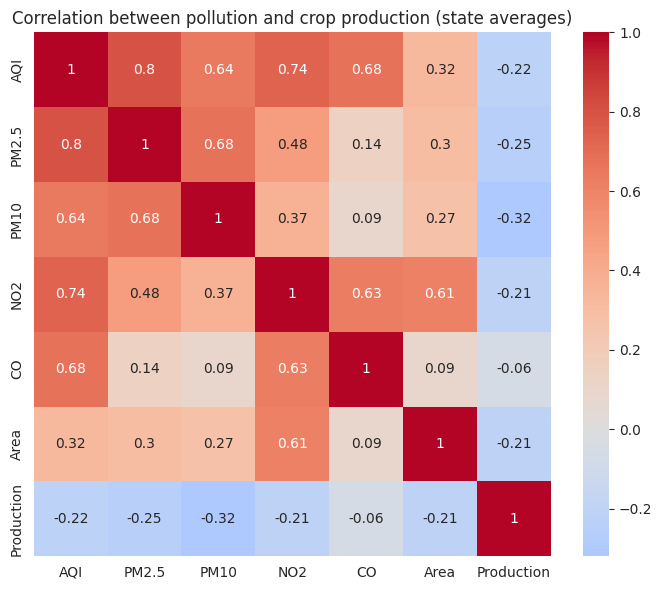

In [25]:
# Correlation matrix across all numeric variables, visualised as a heatmap
corr = merged.corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation between pollution and crop production (state averages)')
plt.tight_layout()
plt.show()


### Two relationships worth explaining

**1. AQI is strongly correlated with CO and NO2 (both around +0.7 to +0.85), but only moderately with PM2.5/PM10.**
This makes sense because CO and NO2 are traffic- and industry-driven pollutants, so states with heavy vehicle and industrial activity (like Gujarat, with its industrial belt) drive AQI up through these gases specifically, while particulate pollution (PM2.5/PM10) is more tied to burning and dust and doesn't move in exactly the same proportion. A correlation matrix shows *that* these move together — it doesn't tell us which pollutant is the actual cause of poor health outcomes or *why* a state has high CO, only that they change together across states.

**2. AQI and average crop production have a weak negative correlation (around -0.2).**
So there's a *slight* tendency for more-polluted states to produce less, but it is far too weak to call a real relationship on its own. A big reason: `Production` mixes crops measured in very different units (most are in tonnes, but coconuts are counted in *number of nuts*, which inflates Kerala and Tamil Nadu's totals by orders of magnitude) — this alone can distort the correlation regardless of pollution. This is a good example of why a correlation matrix needs to be read carefully: it tells you the *strength and direction* of a linear relationship, but nothing about *data quality issues* or *confounding factors* sitting underneath it.


## Task 9 — Briefing for the Minister


> **To: State Environment Minister**
> **Re: Air quality and crop output — what the data shows**
>
> Three things stand out. **First**, air quality has genuinely improved over the past five years — average pollution levels are down by nearly half since 2015, though the most recent year is skewed by lockdowns and shouldn't be over-credited to policy alone. **Second**, pollution is not just a big-city problem — most towns we measured sit in the "moderately polluted" range, so any clean-air programme needs to reach beyond the worst-known hotspots. **Third**, pollution reliably spikes every October–December, lining up with the crop-burning season farmers and NGOs have been flagging — this is the clearest, most actionable pattern in the data.
>
> **What this means for farmers:** the timing points to crop-residue burning as a real contributor to the smoke, but our data alone cannot separate that from winter weather trapping pollution near the ground.
>
> **Recommendation:** fund state support (equipment, subsidies) to help farmers manage crop residue without burning, timed ahead of the October harvest window.
>
> **One honest limitation:** we found only a weak link between a state's pollution and its crop output — not strong enough to say pollution is *causing* lower yields. Rainfall, irrigation, and soil quality likely matter far more, and we do not yet have that data to check.


---
## Optional — Advanced Task

## Task A — The two extremes: do they tell the same story?


In [26]:
# Identify the 3 most and 3 least polluted states (by average AQI) from our state-level table
most_polluted = merged['AQI'].sort_values(ascending=False).head(3)
least_polluted = merged['AQI'].sort_values(ascending=True).head(3)

print("Most polluted states:\n", most_polluted)
print()
print("Least polluted states:\n", least_polluted)


Most polluted states:
 State
Gujarat    315.7
Bihar      234.8
Haryana    220.1
Name: AQI, dtype: float64

Least polluted states:
 State
Mizoram      34.8
Meghalaya    53.8
Kerala       81.0
Name: AQI, dtype: float64


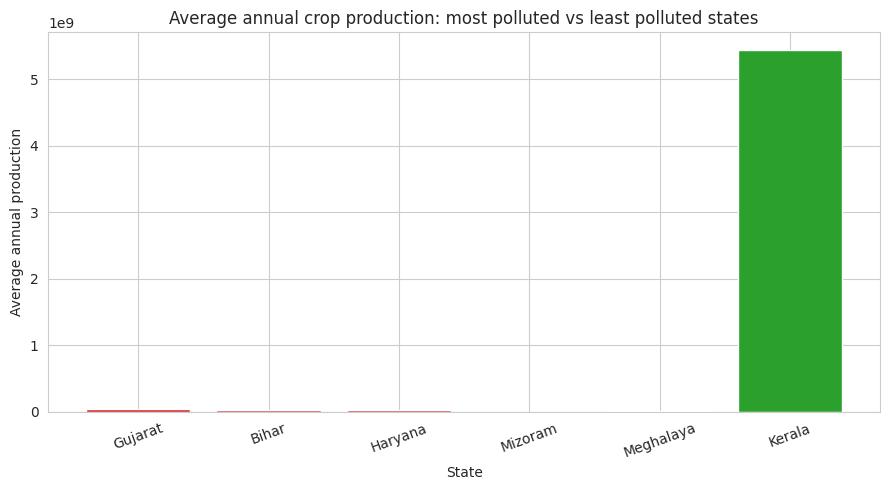

In [27]:
extreme_states = list(most_polluted.index) + list(least_polluted.index)
extreme_df = merged.loc[extreme_states, ['AQI', 'Production']]
group = ['Most polluted']*3 + ['Least polluted']*3
colors = ['#d62728']*3 + ['#2ca02c']*3

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(extreme_df.index, extreme_df['Production'], color=colors)
ax.set_title('Average annual crop production: most polluted vs least polluted states')
ax.set_ylabel('Average annual production')
ax.set_xlabel('State')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Analysis:** The picture is genuinely mixed, not a clean confirmation of the hypothesis. Some of the least polluted states (like Kerala) actually show very high production — largely because of the coconut unit-counting issue noted in Task 8, not because clean air boosts yields. Meanwhile the most polluted states include both very high producers (Gujarat) and modest ones. **This does not cleanly support "more pollution = less production"** — state size, farmland area, and crop mix seem to matter more than air quality alone in this comparison.


## Task B — Put a number on the relationship

Pearson correlation between average AQI and average crop production: r = -0.22
p-value: 0.34


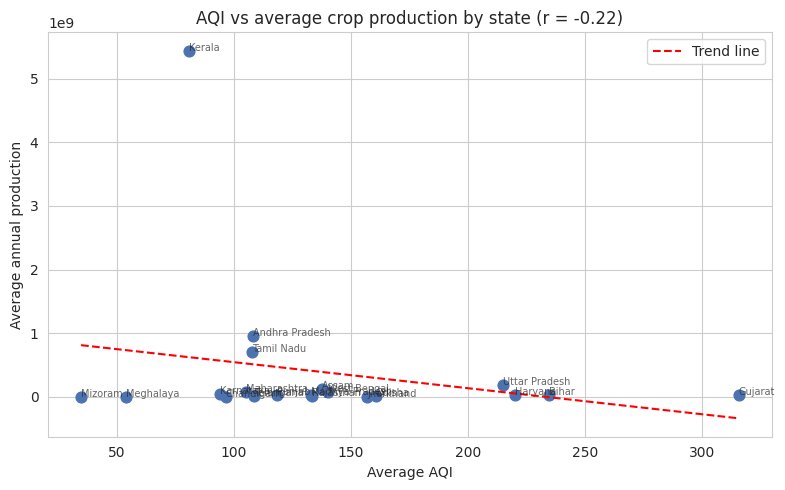

In [28]:
from scipy import stats

r, p_value = stats.pearsonr(merged['AQI'], merged['Production'])
print(f"Pearson correlation between average AQI and average crop production: r = {r:.2f}")
print(f"p-value: {p_value:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged['AQI'], merged['Production'], color='#4C72B0', s=60)

# simple straight-line trend for visual reference
z = np.polyfit(merged['AQI'], merged['Production'], 1)
trend_x = np.linspace(merged['AQI'].min(), merged['AQI'].max(), 50)
ax.plot(trend_x, np.polyval(z, trend_x), color='red', linestyle='--', label='Trend line')

for state in merged.index:
    ax.annotate(state, (merged.loc[state, 'AQI'], merged.loc[state, 'Production']), fontsize=7, alpha=0.7)

ax.set_title(f'AQI vs average crop production by state (r = {r:.2f})')
ax.set_xlabel('Average AQI')
ax.set_ylabel('Average annual production')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation for the research team:** a correlation of about **r ≈ -0.2** is a **weak** negative relationship — for context, values near 0 mean essentially no linear relationship, while values approaching -0.8 or -1.0 would mean a strong, consistent one. At -0.2, pollution explains only a small sliver of the variation in crop production across states; most of the difference between states comes from something else entirely (likely farmland area and crop choice, per the scatterplot). This is **not strong enough evidence to justify funding a causal study on its own** — and even if it were strong, a strong correlation still would not prove pollution *causes* yield loss, since states with high pollution often also differ in industrialisation, urbanisation, and farmland availability, any of which could produce the same pattern.


## Task C — One plot to rule them all

**Chosen plot:** the correlation heatmap from Task 8.

*Caption:* This is the one chart that puts every variable in the same frame at once, and what it reveals is precisely how weak the pollution–production link is compared to how strong the links are between pollution measures themselves. It shows that the "India's smog is starving its farms" narrative isn't well supported by this data — the real story is that pollutants cluster tightly with each other (a genuine, strong signal) while pollution and crop output barely move together at all. No single-variable chart earlier in this notebook could show that contrast; only seeing all the relationships side by side makes clear which pattern is real and which one is closer to noise.

**A note that applies to every optional task above:** correlation is not causation. Even the relationships found here could easily be explained by factors this dataset does not contain at all — rainfall, irrigation access, soil quality, or a state's general economic development — any of which could independently affect both a state's pollution levels and its crop output.
